---
title: Project 1 — Problem 2
---



In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Project 1: project_1_problem_2.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Problem 2 
##########################################################################################


## Problem 2


### Import Machine Learning Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score


### Read Database


In [3]:
# Read data
heart = pd.read_csv("heart1.csv")


### Create Accuracy Results Dictionary


In [4]:
accuracy_results_dict = {}


### Separate Features and Labels in Arrays


In [5]:
X = heart.iloc[:, :-1]
y = heart.iloc[:, -1]


In [6]:
print(heart.shape)


(270, 14)


In [7]:
print(X.shape)


(270, 13)


In [8]:
print(y.shape)


(270,)


In [9]:
print(X[:5])


   age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal
0   29    1    2  130  204    0    2  202    0   0.0      1      0     3
1   34    0    2  118  210    0    0  192    0   0.7      1      0     3
2   34    1    1  118  182    0    2  174    0   0.0      1      0     3
3   35    1    4  120  198    0    0  130    1   1.6      2      0     7
4   35    1    4  126  282    0    2  156    1   0.0      1      0     7


In [10]:
print(y[:5])


0    1
1    1
2    1
3    2
4    2
Name: a1p2, dtype: int64


### Train / Test Split


In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)


In [12]:
print(X_train[:5])


     age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal
5     35    0    4  138  183    0    0  182    0   1.4      1      0     3
221   63    0    3  135  252    0    2  172    0   0.0      1      0     3
131   54    1    4  120  188    0    0  113    0   1.4      2      1     7
162   58    1    4  146  218    0    0  105    0   2.0      2      1     7
222   63    1    4  130  330    1    2  132    1   1.8      1      3     7


In [13]:
print(y_train[:5])


5      1
221    1
131    2
162    2
222    2
Name: a1p2, dtype: int64


In [14]:
print(X_test[:5])


     age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal
63    47    1    4  112  204    0    0  143    0   0.1      1      0     3
254   68    0    3  120  211    0    2  115    0   1.5      2      0     3
234   65    0    3  140  417    1    2  157    0   0.8      1      1     3
56    46    1    4  140  311    0    0  120    1   1.8      2      2     7
151   57    1    4  150  276    0    2  112    1   0.6      2      1     6


In [15]:
print(y_test[:5])


63     1
254    1
234    1
56     2
151    2
Name: a1p2, dtype: int64


### Scale the Training Data


In [16]:
# Standardize for algorithms that need it
sc = StandardScaler()

X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)


In [17]:
print(X_train_std[:2])


[[-2.13215039 -1.44857194  0.91284121  0.33910277 -1.27655761 -0.41702883
  -1.05441535  1.46025029 -0.74965557  0.19486735 -1.01600102 -0.70081094
  -0.90758271]
 [ 0.91246371 -1.44857194 -0.16545247  0.17766594  0.01897451 -0.41702883
   0.95855941  1.02861547 -0.74965557 -0.97433673 -1.01600102 -0.70081094
  -0.90758271]]


In [18]:
print(X_test_std[:2])


[[-0.82731577  0.69033506  0.91284121 -1.06001648 -0.88226523 -0.41702883
  -1.05441535 -0.22312551 -0.74965557 -0.89082215 -1.01600102 -0.70081094
  -0.90758271]
 [ 1.4561448  -1.44857194 -0.16545247 -0.62951825 -0.75083443 -0.41702883
   0.95855941 -1.43170301 -0.74965557  0.27838192  0.58420058 -0.70081094
  -0.90758271]]


## Perceptron


In [19]:
# Perceptron
ppn = Perceptron(
    max_iter=100,
    eta0=0.0001,
    tol=1e-6,
    #fit_intercept=True,
    random_state=0,
    verbose=False
)


In [20]:
ppn.fit(X_train_std, y_train);


In [21]:
y_pred = ppn.predict(X_test_std)


In [22]:
print(y_pred[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [23]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [24]:
print("Perceptron Results:")


Perceptron Results:


In [25]:
preceptron_train_acc = accuracy_score(y_train, ppn.predict(X_train_std))
print(f"Perceptron training accuracy = {preceptron_train_acc:.3f}")


Perceptron training accuracy = 0.847


In [26]:
perceptron_acc = accuracy_score(y_test, y_pred)
print(f"Perceptron testing accuracy = {perceptron_acc:.3f}")


Perceptron testing accuracy = 0.815


In [27]:
# Note that this only counts the samples where the predicted value was wrong
print(f'Misclassified: {(y_test != y_pred).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {perceptron_acc:.3f}')


Misclassified: 15 out of 81 samples.
Accuracy: 0.815


In [28]:
print(f"    Accuracy: {perceptron_acc:.3f}")


    Accuracy: 0.815


In [29]:
accuracy_results_dict.update(
    {
        "Perceptron": perceptron_acc
    })


In [30]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148}


### Get Combined Accuracy


In [31]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
print('Number in combined ',len(y_combined))


Number in combined  270


In [32]:
y_combined_pred = ppn.predict(X_combined_std)


In [33]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [34]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [35]:
perceptron_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Perceptron combined data training accuracy = {perceptron_combined_acc:.3f}")


Perceptron combined data training accuracy = 0.837


In [36]:
# Note that this only counts the samples where the predicted value was wrong
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {perceptron_combined_acc:.3f}')


Misclassified: 44 out of 270 samples.
Accuracy: 0.837


In [37]:
print(f"    Combined: {perceptron_combined_acc:.3f}")
print()


    Combined: 0.837



In [38]:
accuracy_results_dict.update(
    {
        "Perceptron_combined": perceptron_combined_acc
    })


In [39]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037}


## Logistic Regression


In [40]:
#from inspect import signature

#print(signature(LogisticRegression))


In [41]:
# Logistic Regression
LR_accuracy_list = []
c_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
#for c_val in c_vals:
#    lr = LogisticRegression(
#        C            = c_val,
#        solver       = "liblinear",
#        max_iter     = 1000,
#        random_state = 0
#    )
    
#    lr.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, lr.predict(X_test_std))

#    LR_accuracy_list.append(acc)


In [42]:
#print(LR_accuracy_list)


In [43]:
#LR_accuracy_max = max(LR_accuracy_list)
#print(LR_accuracy_max)


In [44]:
#LR_accuracy_max_index = np.argmax(np.array(LR_accuracy_list))
#print(LR_accuracy_max_index)


In [45]:
# Best accuracy with index 1
LR_accuracy_max_index = 1


In [46]:
lr_used = \
    LogisticRegression(
        C            = c_vals[LR_accuracy_max_index],
        solver       = "liblinear",
        max_iter     = 1000,
        random_state = 0
    )
    
lr_used.fit(X_train_std, y_train);


In [47]:
y_pred = lr_used.predict(X_test_std)


In [48]:
print(y_pred[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [49]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [50]:
print("Logistic Regression Results:")


Logistic Regression Results:


In [51]:
lr_train_acc = accuracy_score(y_train, lr_used.predict(X_train_std))
print(f"Logistic Regression training accuracy = {lr_train_acc:.3f}")


Logistic Regression training accuracy = 0.873


In [52]:
lr_acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression testing accuracy = {lr_acc:.3f}")


Logistic Regression testing accuracy = 0.864


In [53]:
print(f'Misclassified: {(y_test != y_pred).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {lr_acc:.3f}')


Misclassified: 11 out of 81 samples.
Accuracy: 0.864


In [54]:
print(f"    Accuracy: {lr_acc:.3f}")


    Accuracy: 0.864


In [55]:
accuracy_results_dict.update(
    {
        "LR": lr_acc
    })


In [56]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975}


### Get Combined Accuracy


In [57]:
lr_combined_used = \
    LogisticRegression(
        C            = c_vals[LR_accuracy_max_index],
        solver       = "liblinear",
        max_iter     = 1000,
        random_state = 0
    )
    
lr_combined_used.fit(X_combined_std, y_combined);


In [58]:
y_combined_pred = lr_combined_used.predict(X_combined_std)


In [59]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [60]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [61]:
lr_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Logistic Regression combined data testing accuracy = {lr_combined_acc:.3f}")


Logistic Regression combined data testing accuracy = 0.852


In [62]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {lr_combined_acc:.3f}')


Misclassified: 40 out of 270 samples.
Accuracy: 0.852


In [63]:
print(f"    Combined Accuracy: {lr_combined_acc:.3f}")
print()


    Combined Accuracy: 0.852



In [64]:
accuracy_results_dict.update(
    {
        "LR_combined": lr_combined_acc
    })


In [65]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519}


## Support Vector Machine


In [66]:
#from inspect import signature

#print(signature(SVC))


In [67]:
#SVM_accuracy_list = []
#degree_vals = list(range(0,7))

#for degree in degree_vals:
#    svm = SVC(
#        C            = 0.01,
#        degree       = degree,
#        kernel       = "linear",
#        max_iter     = -1,
#        random_state = 0
#    )
    
#    svm.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, svm.predict(X_test_std))

#    SVM_accuracy_list.append(acc)


In [68]:
#print(SVM_accuracy_list)


In [69]:
SVM_accuracy_list = []
c_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

#for c_val in c_vals:
#    svm = SVC(
#        C            = c_val,
#        kernel       = "linear",
#        max_iter     = -1,
#        random_state = 0
#    )
    
#    svm.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, svm.predict(X_test_std))

#    SVM_accuracy_list.append(acc)


In [70]:
#print(SVM_accuracy_list)


In [71]:
#SVM_accuracy_max = max(SVM_accuracy_list)
#print(SVM_accuracy_max)


In [72]:
#SVM_accuracy_max_index = np.argmax(np.array(SVM_accuracy_list))
#print(SVM_accuracy_max_index)


In [73]:
# Best accuracy index = 1
SVM_accuracy_max_index = 1


In [74]:
SVM_used = \
    SVC(
        C            = c_vals[SVM_accuracy_max_index],
        kernel       = "linear",
        max_iter     = -1,
        random_state = 0,
        verbose      = False
    )
    
SVM_used.fit(X_train_std, y_train);


In [75]:
y_pred = SVM_used.predict(X_test_std)


In [76]:
print(y_pred[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [77]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [78]:
print("Support Vector Machine Results:")


Support Vector Machine Results:


In [79]:
SVM_train_acc = accuracy_score(y_train, SVM_used.predict(X_train_std))
print(f"SVM training accuracy = {SVM_train_acc:.3f}")


SVM training accuracy = 0.868

In [80]:
SVM_acc = accuracy_score(y_test, y_pred)
print(f"SVM testing accuracy = {SVM_acc:.3f}")


SVM testing accuracy = 0.852


In [81]:
print(f'Misclassified: {(y_test != y_pred).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {SVM_acc:.3f}')


Misclassified: 12 out of 81 samples.
Accuracy: 0.852


In [82]:
print(f"    Accuracy: {SVM_acc:.3f}")


    Accuracy: 0.852


In [83]:
accuracy_results_dict.update(
    {
        "SVM": SVM_acc
    })


In [84]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519}


### Get Combined Accuracy


In [85]:
SVM_combined_used = \
    SVC(
        C            = c_vals[SVM_accuracy_max_index],
        kernel       = "linear",
        max_iter     = -1,
        random_state = 0,
        verbose      = False
    )
    
SVM_combined_used.fit(X_combined_std, y_combined);


In [86]:
y_combined_pred = SVM_combined_used.predict(X_combined_std)


In [87]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [88]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [89]:
SVM_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"SVM combined data testing accuracy = {SVM_combined_acc:.3f}")


SVM combined data testing accuracy = 0.859


In [90]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {SVM_combined_acc:.3f}')


Misclassified: 38 out of 270 samples.
Accuracy: 0.859


In [91]:
print(f"    Combined Accuracy: {SVM_combined_acc:.3f}")
print()


    Combined Accuracy: 0.859



In [92]:
accuracy_results_dict.update(
    {
        "SVM_combined": SVM_combined_acc
    })


In [93]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593}


## Decision Tree


In [94]:
#from inspect import signature

#print(signature(DecisionTreeClassifier))


In [95]:
print(list(range(1,11)))


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [96]:
#DTree_accuracy_list = []
#depth_vals = list(range(1,11))

#for depth in depth_vals:
#    tree = DecisionTreeClassifier(
#        criterion       = 'entropy',
#        max_depth       = depth,
#        random_state    = 0
#    )
    
#    tree.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, tree.predict(X_test_std))

#    DTree_accuracy_list.append(acc)


In [97]:
#print(DTree_accuracy_list)


In [98]:
DTree_accuracy_list = []
depth_vals = list(range(1,11))

#for depth in depth_vals:
#    tree = DecisionTreeClassifier(
#        criterion       = 'gini',
#        max_depth       = depth,
#        random_state    = 0
#    )
    
#    tree.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, tree.predict(X_test_std))

#    DTree_accuracy_list.append(acc)


In [99]:
#print(DTree_accuracy_list)


In [100]:
#DTree_accuracy_max = max(DTree_accuracy_list)
#print(DTree_accuracy_max)


In [101]:
#DTree_accuracy_max_index = np.argmax(np.array(DTree_accuracy_list))
#print(DTree_accuracy_max_index)


In [102]:
# Best accuracy index = 2
DTree_accuracy_max_index = 2


In [103]:
DTree_used = \
    DecisionTreeClassifier(
        criterion       = 'gini',
        max_depth       = depth_vals[DTree_accuracy_max_index],
        random_state    = 0
    )
    
DTree_used.fit(X_train_std, y_train);


In [104]:
y_pred = DTree_used.predict(X_test_std)


In [105]:
print(y_pred[0:10])


[1 1 1 2 2 1 1 2 2 2]


In [106]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [107]:
print("Decision Tree Results:")


Decision Tree Results:


In [108]:
DTree_train_acc = accuracy_score(y_train, DTree_used.predict(X_train_std))
print(f"Decision Tree training accuracy = {DTree_train_acc:.3f}")


Decision Tree training accuracy = 0.894


In [109]:
DTree_acc = accuracy_score(y_test, y_pred)
print(f"Decision Tree testing accuracy = {DTree_acc:.3f}")


Decision Tree testing accuracy = 0.802


In [110]:
print(f'Misclassified: {(y_test != y_pred).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {DTree_acc:.3f}')


Misclassified: 16 out of 81 samples.
Accuracy: 0.802


In [111]:
print(f"    Accuracy: {DTree_acc:.3f}")


    Accuracy: 0.802


In [112]:
accuracy_results_dict.update(
    {
        "DTree": DTree_acc
    })


In [113]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593, 'DTree': 0.8024691358024691}


### Get Combined Accuracy


In [114]:
DTree_combined_used = \
    DecisionTreeClassifier(
        criterion       = 'gini',
        max_depth       = depth_vals[DTree_accuracy_max_index],
        random_state    = 0
    )
    
DTree_combined_used.fit(X_combined_std, y_combined);


In [115]:
y_combined_pred = DTree_combined_used.predict(X_combined_std)


In [116]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 2 2 2 2]


In [117]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [118]:
DTree_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Decision Tree combined data testing accuracy = {DTree_combined_acc:.3f}")


Decision Tree combined data testing accuracy = 0.863


In [119]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {DTree_combined_acc:.3f}')


Misclassified: 37 out of 270 samples.
Accuracy: 0.863


In [120]:
print(f"    Combined Accuracy: {DTree_combined_acc:.3f}")
print()


    Combined Accuracy: 0.863



In [121]:
accuracy_results_dict.update(
    {
        "DTree_combined": DTree_combined_acc
    })


In [122]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593, 'DTree': 0.8024691358024691, 'DTree_combined': 0.8629629629629629}


## Random Forest


In [123]:
#from inspect import signature

#print(signature(RandomForestClassifier))


In [124]:
RForest_accuracy_list = []
num_tree_vals = [1, 5, 11, 51, 101, 501, 1001]

#for num_trees in num_tree_vals:
#    forest = RandomForestClassifier(
#        criterion       = 'entropy',
#        n_estimators    = num_trees,
#        random_state    = 0,
#        n_jobs          = 8
#    )
    
#    forest.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, forest.predict(X_test_std))

#    RForest_accuracy_list.append(acc)


In [125]:
#print(RForest_accuracy_list)


In [126]:
#RForest_accuracy_max = max(RForest_accuracy_list)
#print(RForest_accuracy_max)


In [127]:
#RForest_accuracy_max_index = np.argmax(np.array(RForest_accuracy_list))
#print(RForest_accuracy_max_index)


In [128]:
# Best Accuracy Index = 3
RForest_accuracy_max_index = 3


In [129]:
RForest_used = \
    RandomForestClassifier(
        criterion       = 'entropy',
        n_estimators    = num_tree_vals[RForest_accuracy_max_index],
        random_state    = 0,
        n_jobs          = 8
    )
    
RForest_used.fit(X_train_std, y_train);


In [130]:
y_pred = RForest_used.predict(X_test_std)


In [131]:
print(y_pred[0:10])


[1 1 1 2 2 1 1 2 2 2]


In [132]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [133]:
print("Random Forest Results:")


Random Forest Results:


In [134]:
RForest_train_acc = accuracy_score(y_train, RForest_used.predict(X_train_std))
print(f"Random Forest training accuracy = {RForest_train_acc:.3f}")


Random Forest training accuracy = 1.000


In [135]:
RForest_acc = accuracy_score(y_test, y_pred)
print(f"Random Forest testing accuracy = {RForest_acc:.3f}")


Random Forest testing accuracy = 0.827


In [136]:
print(f'Misclassified: {(y_test != y_pred).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {RForest_acc:.3f}')


Misclassified: 14 out of 81 samples.
Accuracy: 0.827


In [137]:
print(f"    Accuracy: {RForest_acc:.3f}")


    Accuracy: 0.827


In [138]:
accuracy_results_dict.update(
    {
        "RForest": RForest_acc
    })


In [139]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593, 'DTree': 0.8024691358024691, 'DTree_combined': 0.8629629629629629, 'RForest': 0.8271604938271605}


### Get Combined Accuracy


In [140]:
RForest_combined_used = \
    RandomForestClassifier(
        criterion       = 'entropy',
        n_estimators    = num_tree_vals[RForest_accuracy_max_index],
        random_state    = 0,
        n_jobs          = 8
    )
    
RForest_combined_used.fit(X_combined_std, y_combined);


In [141]:
y_combined_pred = RForest_combined_used.predict(X_combined_std)


In [142]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [143]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [144]:
RForest_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Random Forest combined data testing accuracy = {RForest_combined_acc:.3f}")


Random Forest combined data testing accuracy = 1.000


In [145]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {RForest_combined_acc:.3f}')


Misclassified: 0 out of 270 samples.
Accuracy: 1.000


In [146]:
print(f"    Combined Accuracy: {RForest_combined_acc:.3f}")
print()


    Combined Accuracy: 1.000



In [147]:
accuracy_results_dict.update(
    {
        "RForest_combined": RForest_combined_acc
    })


In [148]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593, 'DTree': 0.8024691358024691, 'DTree_combined': 0.8629629629629629, 'RForest': 0.8271604938271605, 'RForest_combined': 1.0}


## K - Nearest Neighbor (KNN)


In [149]:
#from inspect import signature

#print(signature(KNeighborsClassifier))


In [150]:
print(list(range(1,51)))


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


In [151]:
KNN_accuracy_list = []
k_vals = list(range(1,51))

#for k_val in k_vals:
#    knn = KNeighborsClassifier(
#        n_neighbors = k_val,
#        n_jobs = 8
#    )
    
#    knn.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, knn.predict(X_test_std))

#    KNN_accuracy_list.append(acc)


In [152]:
#print(KNN_accuracy_list)


In [153]:
#KNN_accuracy_max = max(KNN_accuracy_list)
#print(KNN_accuracy_max)


In [154]:
#KNN_accuracy_max_index = np.argmax(np.array(KNN_accuracy_list))
#print(KNN_accuracy_max_index)


In [155]:
#print(f"Maximum KNN accuracy achieved with K = {k_vals[KNN_accuracy_max_index]}")


In [156]:
# Best Accuracy Index = 32
KNN_accuracy_max_index = 32


In [157]:
KNN_used = \
    KNeighborsClassifier(
        n_neighbors = k_vals[KNN_accuracy_max_index],
        n_jobs = 8
    )
    
KNN_used.fit(X_train_std, y_train);


In [158]:
y_pred = KNN_used.predict(X_test_std)


In [159]:
print(y_pred[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [160]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [161]:
print("K - Nearest Neighbor (KNN) Results:")


K - Nearest Neighbor (KNN) Results:


In [162]:
KNN_train_acc = accuracy_score(y_train, KNN_used.predict(X_train_std))
print(f"KNN training accuracy = {KNN_train_acc:.3f}")


KNN training accuracy = 0.868


In [163]:
KNN_acc = accuracy_score(y_test, y_pred)
print(f"KNN testing accuracy = {KNN_acc:.3f}")


KNN testing accuracy = 0.864


In [164]:
print(f'Misclassified: {(y_test != y_pred).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {KNN_acc:.3f}')


Misclassified: 11 out of 81 samples.
Accuracy: 0.864


In [165]:
print(f"    Accuracy: {KNN_acc:.3f}")


    Accuracy: 0.864


In [166]:
accuracy_results_dict.update(
    {
        "KNN": KNN_acc
    })


In [167]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593, 'DTree': 0.8024691358024691, 'DTree_combined': 0.8629629629629629, 'RForest': 0.8271604938271605, 'RForest_combined': 1.0, 'KNN': 0.8641975308641975}


### Get Combined Accuracy


In [168]:
KNN_combined_used = \
    KNeighborsClassifier(
        n_neighbors = k_vals[KNN_accuracy_max_index],
        n_jobs = 8
    )
    
KNN_combined_used.fit(X_combined_std, y_combined);


In [169]:
y_combined_pred = KNN_combined_used.predict(X_combined_std)


In [170]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [171]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [172]:
KNN_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"KNN combined data testing accuracy = {KNN_combined_acc:.3f}")


KNN combined data testing accuracy = 0.852


In [173]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {KNN_combined_acc:.3f}')


Misclassified: 40 out of 270 samples.
Accuracy: 0.852


In [174]:
print(f"    Combined Accuracy: {KNN_combined_acc:.3f}")
print()


    Combined Accuracy: 0.852



In [175]:
accuracy_results_dict.update(
    {
        "KNN_combined": KNN_combined_acc
    })


In [176]:
print(accuracy_results_dict)


{'Perceptron': 0.8148148148148148, 'Perceptron_combined': 0.837037037037037, 'LR': 0.8641975308641975, 'LR_combined': 0.8518518518518519, 'SVM': 0.8518518518518519, 'SVM_combined': 0.8592592592592593, 'DTree': 0.8024691358024691, 'DTree_combined': 0.8629629629629629, 'RForest': 0.8271604938271605, 'RForest_combined': 1.0, 'KNN': 0.8641975308641975, 'KNN_combined': 0.8518518518518519}


## Create Accuracy Results Dataframe


In [177]:
df_accuracy_results = \
    pd.DataFrame(
        accuracy_results_dict.items(),
        columns = ['Algorithm', 'Accuracy']
    )
print(df_accuracy_results)


              Algorithm  Accuracy
0            Perceptron  0.814815
1   Perceptron_combined  0.837037
2                    LR  0.864198
3           LR_combined  0.851852
4                   SVM  0.851852
5          SVM_combined  0.859259
6                 DTree  0.802469
7        DTree_combined  0.862963
8               RForest  0.827160
9      RForest_combined  1.000000
10                  KNN  0.864198
11         KNN_combined  0.851852


In [178]:
df_accuracy_results = df_accuracy_results.sort_values(
    by="Accuracy",
    ascending=False
)


In [179]:
print(df_accuracy_results)


              Algorithm  Accuracy
9      RForest_combined  1.000000
2                    LR  0.864198
10                  KNN  0.864198
7        DTree_combined  0.862963
5          SVM_combined  0.859259
3           LR_combined  0.851852
4                   SVM  0.851852
11         KNN_combined  0.851852
1   Perceptron_combined  0.837037
8               RForest  0.827160
0            Perceptron  0.814815
6                 DTree  0.802469


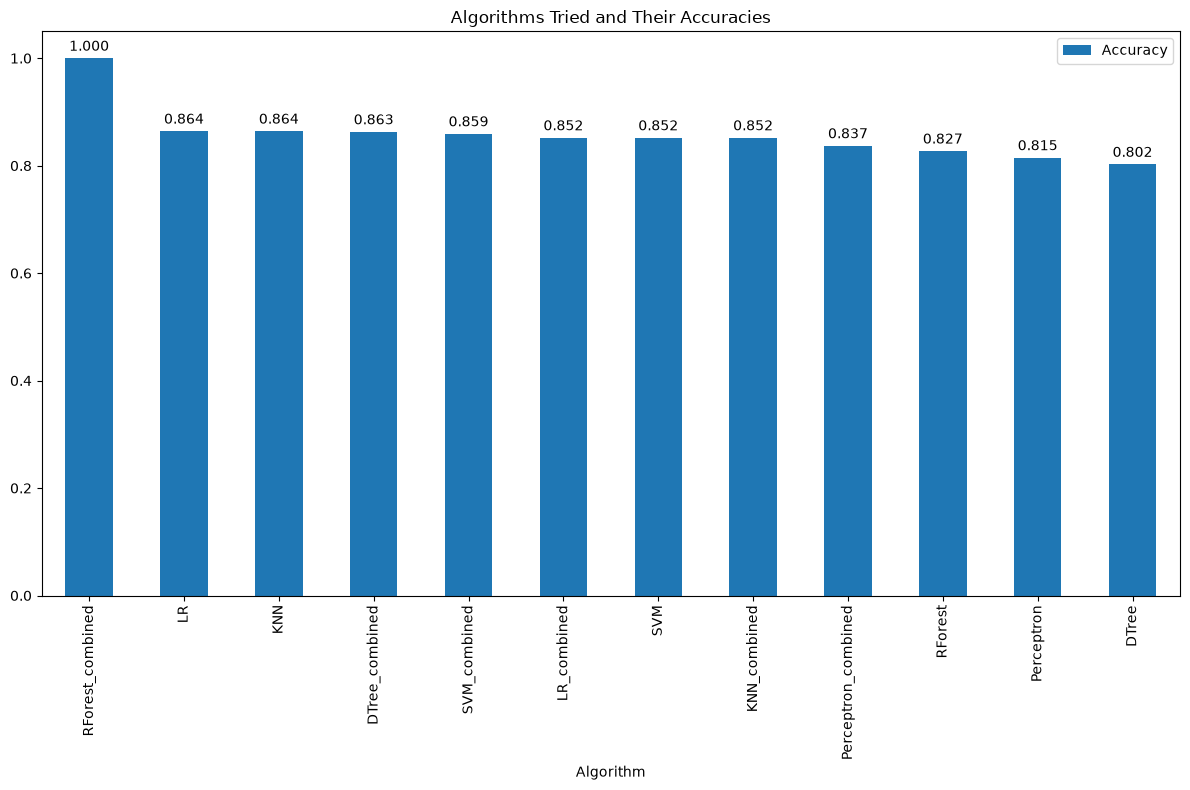

In [180]:
df_accuracy_results = df_accuracy_results.sort_values(
    by="Accuracy",
    ascending=False
)

ax = df_accuracy_results.plot.bar(
    x="Algorithm",
    y="Accuracy",
    figsize=(12,8),
    title="Algorithms Tried and Their Accuracies"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',      # 3 digits after decimal
        padding=3
    )
    
plt.tight_layout()
plt.show()
